In [1]:
%run ~/analysisLibraries

In [2]:
%matplotlib inline

In [3]:
%load_ext rpy2.ipython

## Read data containing all necessary scores and relevant genes calculated in the previous notebook

In [4]:
adata = sc.read('./write/SDA_object_100comps.h5ad')

component can be changed using the software papermill to execute notebooks in the workflow

In [5]:
comp=0

In [6]:
# Parameters
comp = 72


## Open SDA matrices

In [7]:
A = pd.read_csv('ALLDATA_scaled_onematrix_data_100comps/it2000/A', sep=' ', header=None)
#B is only for multi-tissues tensor
#B = pd.read_csv('SDA/CELLS_sctransform_onematrix_data/it2000/B1', sep=' ', header=None)
X = pd.read_csv('ALLDATA_scaled_onematrix_data_100comps/it2000/X1', sep=' ', header=None)

$A$ contains the score of each cell in the components. This score can be used as a "soft clustering" once it is normalized. We will try to do that in the notebook that follows this one. 

In [8]:
A.shape

(10548, 100)

In [9]:
A.head()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.237044,-0.444741,-0.521709,-0.421176,-0.191632,-0.039443,-0.011519,0.313026,-0.017442,-0.014353,...,-0.713952,0.084345,0.325848,0.577062,-0.704971,-0.307896,0.102466,-0.919935,-0.196817,-1.101270
1,0.411126,-0.113899,-0.404359,-0.412903,0.112982,-0.168036,-0.364643,0.746365,-0.003497,-0.242012,...,0.923655,-0.432896,0.018581,-0.329805,-0.004898,-0.298961,0.290554,0.328762,-0.211422,0.605521
2,-0.554124,-2.115210,0.572701,-0.509780,0.577237,-0.234850,0.450509,0.208679,0.177719,-0.164977,...,-0.382789,0.511820,0.686443,0.116738,-0.315359,-0.109686,1.740900,-0.937221,0.846761,0.562644
3,-0.258430,1.402740,1.303190,-0.759115,1.298820,-0.058847,-0.725280,-0.359907,0.306425,1.195000,...,-0.727815,0.416148,2.020470,-0.108066,-0.465147,-1.716540,0.712520,-0.855888,0.907461,0.266163
4,-0.338097,1.336100,-1.538940,0.907896,0.817900,1.415150,-0.130066,-0.545487,-0.755909,-0.912024,...,-1.259190,-0.325736,0.157799,1.454890,-0.115039,-0.391225,1.149520,0.961979,-0.198099,0.624347


In [10]:
#B

$X$ contains the loading of each gene in each component according to the spike-and-slab prior. The sign of the loading has to be considered together with the sign of the cell score to see if the resulting sign is positive (significant expression of gene) or negative (significant underexpression of gene)

In [11]:
X.columns = adata[:,(np.log(adata.var['variance-Cells'])>0)|(np.log(adata.var['variance-Nuclei']>-1))].var_names

In [12]:
X.shape

(100, 6276)

In [13]:
X.head()

,AURKAIP1,MRPL20,SSU72,LOC469457,GNB1,MORN1,RER1,MMEL1,ACTRT2,CCDC27,...,amplicon-chrX-FAM9A/B/C-6,amplicon-chrX-GAGE10-0,amplicon-chrX-LOC107966365-0,amplicon-chrX-LOC112206844-0,amplicon-chrX-LOC112206844-2,amplicon-chrX-LOC112206844-4,amplicon-chrX-LOC465705-2,amplicon-chrX-PAGE5-3,amplicon-chrX-SPANXN5-2,amplicon-chrX-SSX1/3/2B-15
0,-0.251518,-0.050381,-0.000772,-0.082587,-0.000094,-0.001789,-0.132522,0.000048,-0.053861,-0.035661,...,0.000333,0.000363,-0.000149,-0.036358,-0.000366,0.002521,-0.061503,0.000056,0.000141,0.006134
1,0.000395,0.000193,-0.000607,0.001750,0.000787,-0.001956,-0.000217,-0.000121,0.000535,-0.000017,...,0.066423,-0.000271,0.000069,0.029602,0.001012,0.000030,-0.000178,0.000639,-0.026457,0.000855
2,-0.000250,-0.000108,-0.000195,0.030246,0.000202,-0.001048,-0.000112,0.000151,-0.001854,-0.000145,...,-0.000141,0.001418,-0.000997,-0.000141,-0.039148,-0.000122,0.000968,-0.000012,-0.001109,0.000334
3,0.000423,-0.000399,-0.000322,0.002582,0.000288,0.000177,-0.000765,0.046786,0.000218,0.000263,...,-0.000404,0.000993,0.000137,0.000224,0.043691,-0.000044,0.000219,0.000187,0.000062,-0.000340
4,-0.000056,-0.000013,0.000059,-0.000223,0.033124,-0.000006,0.000276,-0.107145,0.000001,-0.051293,...,-0.034791,0.000032,0.061013,-0.000074,-0.000050,0.000003,0.000006,0.000007,-0.000034,-0.037562


## Some plots and measures about the specific components

#### UMAP of cell scores and batches

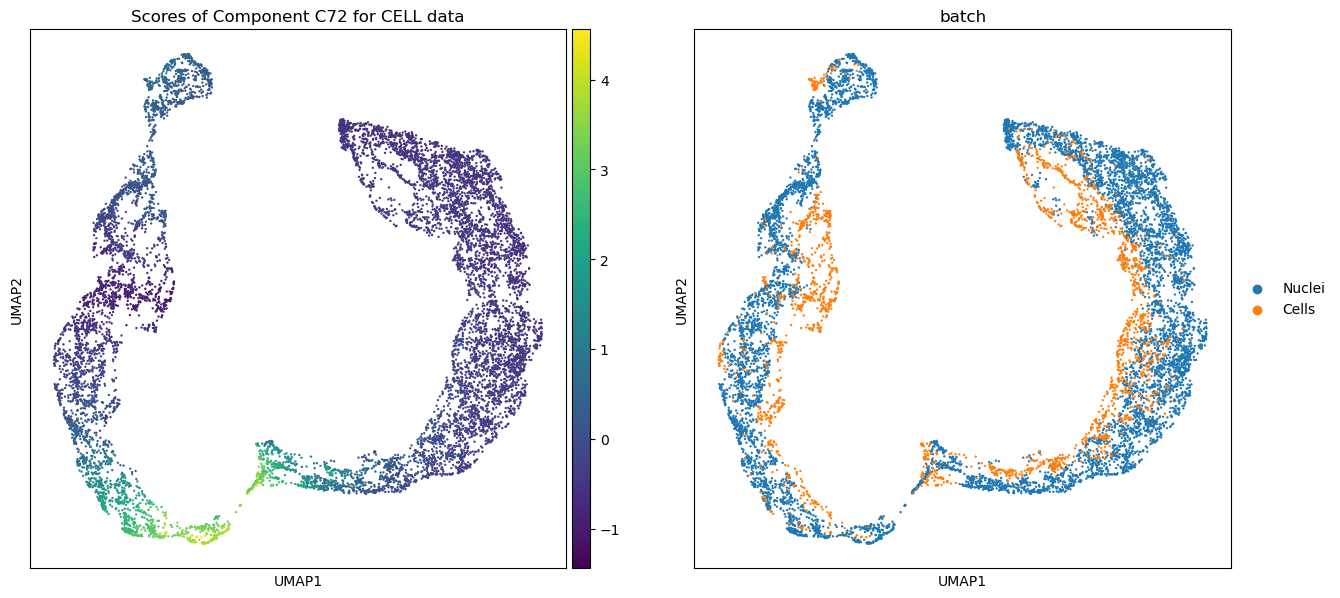

In [14]:
plt.rcParams['figure.figsize']=(7,7)
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}','batch'],
          title=f'Scores of Component C{comp} for CELL data')

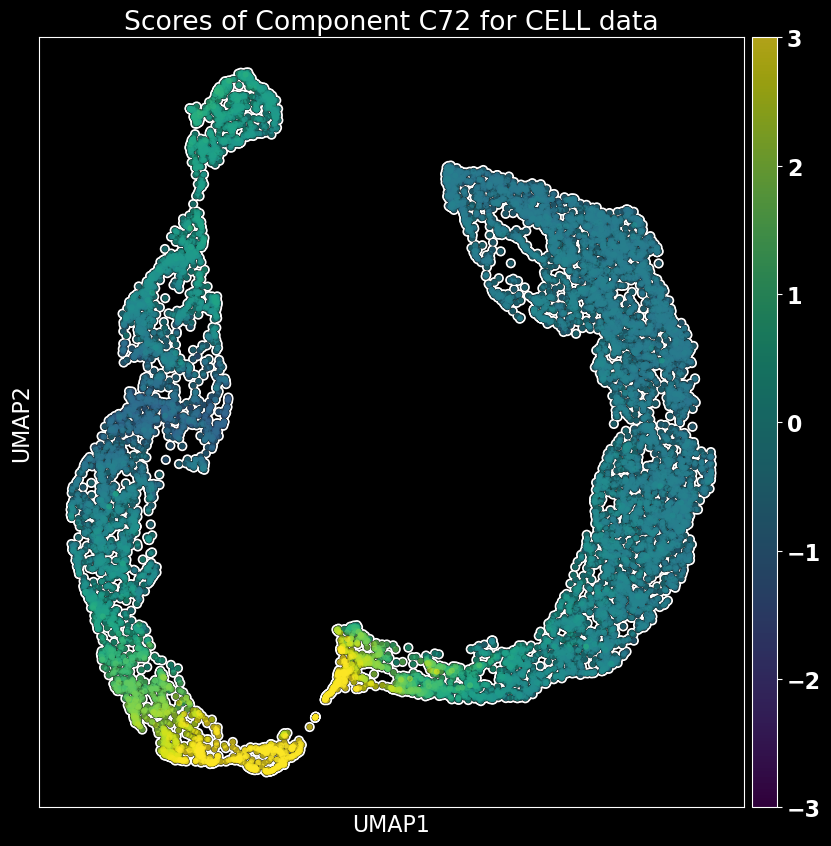

In [15]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('dark_background')
plt.rc('font', size=16, weight='bold')
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}'], vmin=-3, vmax=3, 
          title=f'Scores of Component C{comp} for CELL data', size=75,
          add_outline=True, outline_color=['white','black'],
          save=f'scores_C{comp}_dark.png', )

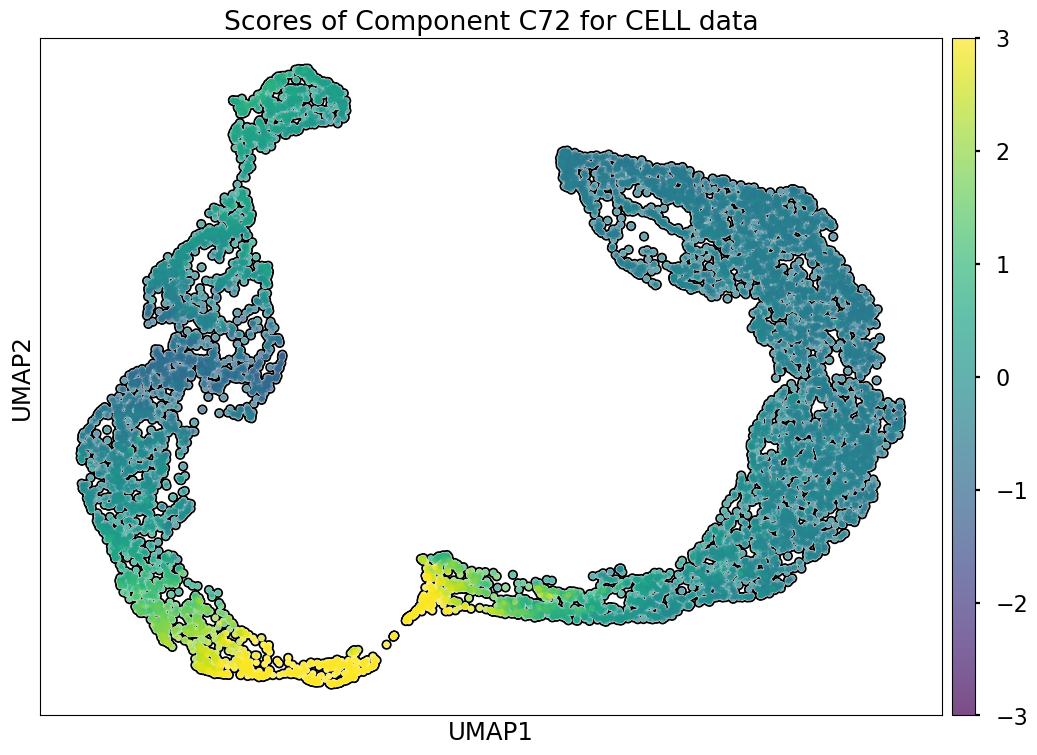

In [16]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}'], vmin=-3, vmax=3, 
          title=f'Scores of Component C{comp} for CELL data', size=75,
          add_outline=True,
          save=f'scores_C{comp}_white.png', )

In [17]:
try:
    IRRELEVANT=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['IRRELEVANT']
except Exception as e:
    IRRELEVANT=0
try:
    POSITIVE=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['POSITIVE']
except Exception as e:
    POSITIVE=0
try:
    NEGATIVE=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['NEGATIVE']
except Exception as e:
     NEGATIVE=0

In [18]:
onlyrelevant = np.array( adata.obs[f'sda_cell_relevant_C{comp}'].copy() )
onlyrelevant[onlyrelevant=='IRRELEVANT']=None
adata.obs[f'sda_cell_relevantonly_C{comp}'] = onlyrelevant

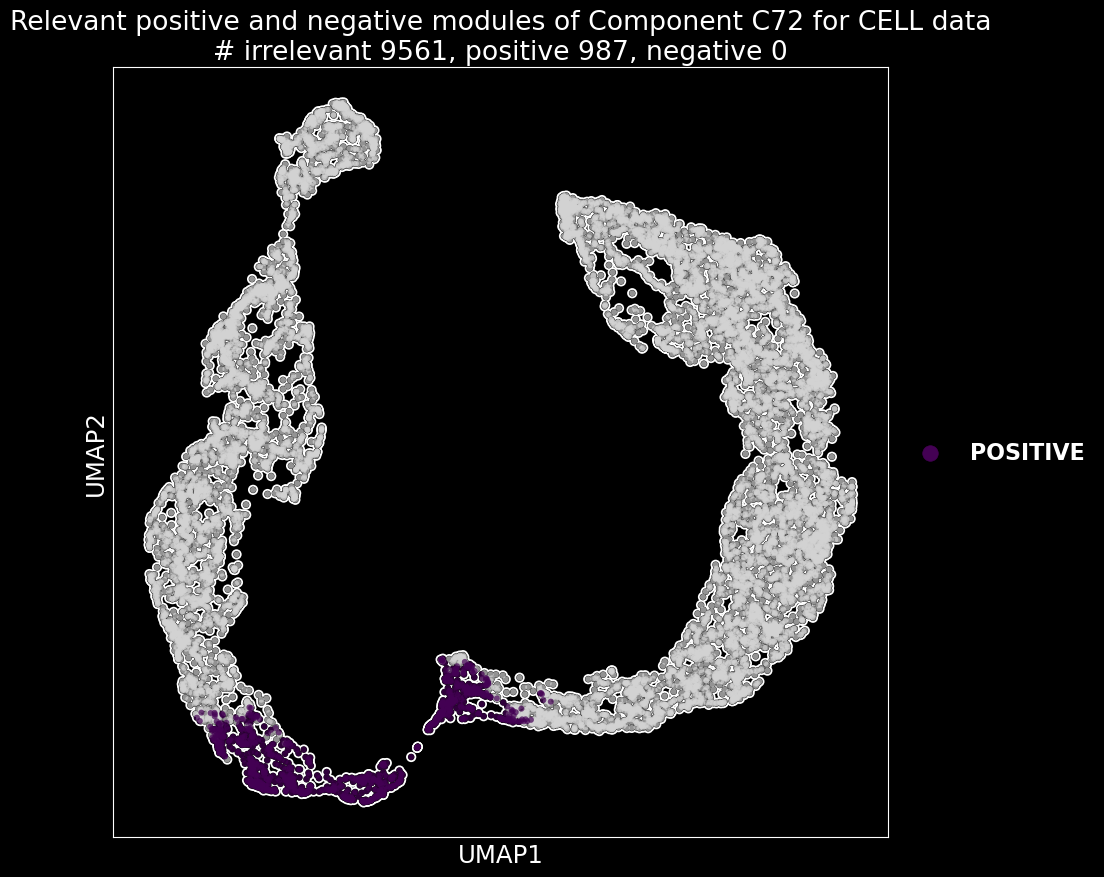

In [19]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('dark_background')
plt.rc('font', size=16, weight='bold')
sc.pl.umap(adata, color=[f'sda_cell_relevantonly_C{comp}'], vmin=-3, vmax=3, na_in_legend=False, na_color='lightgray',
          title=f'Relevant positive and negative modules of Component C{comp} for CELL data\n# irrelevant {IRRELEVANT}, positive {POSITIVE}, negative {NEGATIVE}', 
          size=75, add_outline=True, outline_color=['white','black'], palette='viridis',
          save=f'relevance_C{comp}_dark.png')

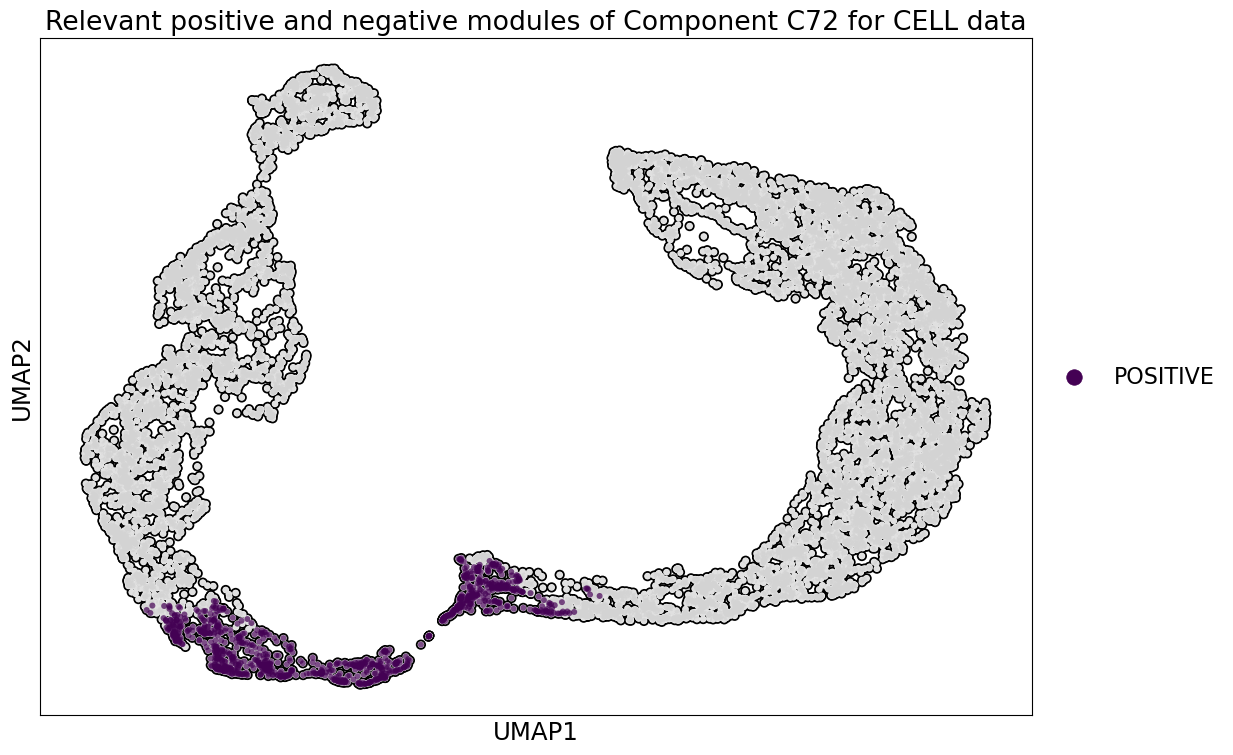

In [20]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'sda_cell_relevantonly_C{comp}'], vmin=-3, vmax=3, na_in_legend=False, na_color='lightgray',
          title=f'Relevant positive and negative modules of Component C{comp} for CELL data', palette='viridis',
          size=75, add_outline=True,
          save=f'relevance_C{comp}_white.png')

### mean and std of positive and negative cell scores for each batch

In [21]:
score_cells = adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}']
score_nuclei = adata[adata.obs['batch']=='Nuclei'].obs[f'SDA_cellscore_C{comp}']

In [22]:
print( 'Positive scores nuclei - mean:', np.mean(score_nuclei[score_nuclei>1.5]), 'var:', np.std(score_nuclei[score_nuclei>1.5])  )
print( 'Positive scores cells  - mean:', np.mean(score_cells[score_cells>2]), 'var:', np.std(score_cells[score_cells>2])  )

Positive scores nuclei - mean: 2.628683795620438 var: 0.6930179657029485
Positive scores cells  - mean: 2.9102518181818184 var: 0.6611518113938898


In [23]:
print( 'Negative scores nuclei - mean:', np.mean(score_nuclei[score_nuclei<-1.5]), 'var:', np.std(score_nuclei[score_nuclei<-1.5])  )
print( 'Negative scores cells  - mean:', np.mean(score_cells[score_cells<-2]), 'var:', np.std(score_cells[score_cells<-2])  )

Negative scores nuclei - mean: nan var: nan
Negative scores cells  - mean: nan var: nan


### T-test to detect batch differences in a module

We check if positive/negative scores are specific for either cells or genes, so we can highlight that in our information output

In [24]:
import scipy

Two-sided test of positive scores of cells vs nuclei

In [25]:
scipy.stats.ttest_ind( score_cells[score_cells>0], score_nuclei[score_nuclei>0])

Ttest_indResult(statistic=-1.2824757713243617, pvalue=0.19976933328947558)

Two-sided test of negative scores of cells vs nuclei

In [26]:
scipy.stats.ttest_ind( score_cells[score_cells<0], score_nuclei[score_nuclei<0])

Ttest_indResult(statistic=4.051906221902803, pvalue=5.132416846740517e-05)

Cells have more transcripts than nuclei and this is reflected in a bit higher/lower score in general, so we choose a strict threshold to avoid detecting batch differences where they are mostly due to technical causes

In [27]:
pos_stat, pos_p = scipy.stats.ttest_ind( score_cells[score_cells>0], score_nuclei[score_nuclei>0])
neg_stat, neg_p = scipy.stats.ttest_ind( score_cells[score_cells<0], score_nuclei[score_nuclei<0])

batch_effect_pos='No'
batch_effect_neg='No'

if np.abs(pos_stat) > 10:
    batch_effect_pos='Yes'
print(f'Positive module batch differences: {batch_effect_pos}')
    
if np.abs(neg_stat) > 10:
    batch_effect_neg='Yes'
print(f'Negative module batch differences: {batch_effect_neg}')

Positive module batch differences: No
Negative module batch differences: No


<Axes: xlabel='SDA_cellscore_C72', ylabel='Count'>

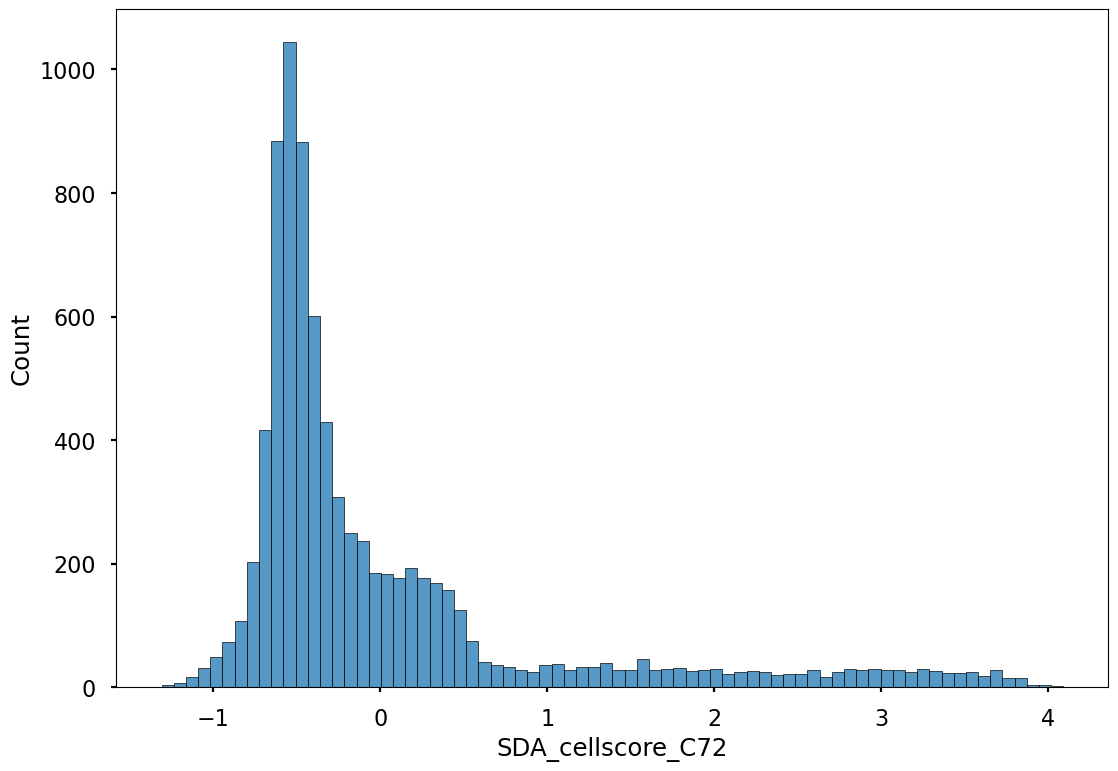

In [28]:
plt.rcParams['figure.figsize']=(6,6)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sns.histplot(adata[adata.obs['batch']=='Nuclei'].obs[f'SDA_cellscore_C{comp}'])

<Axes: xlabel='SDA_cellscore_C72', ylabel='Count'>

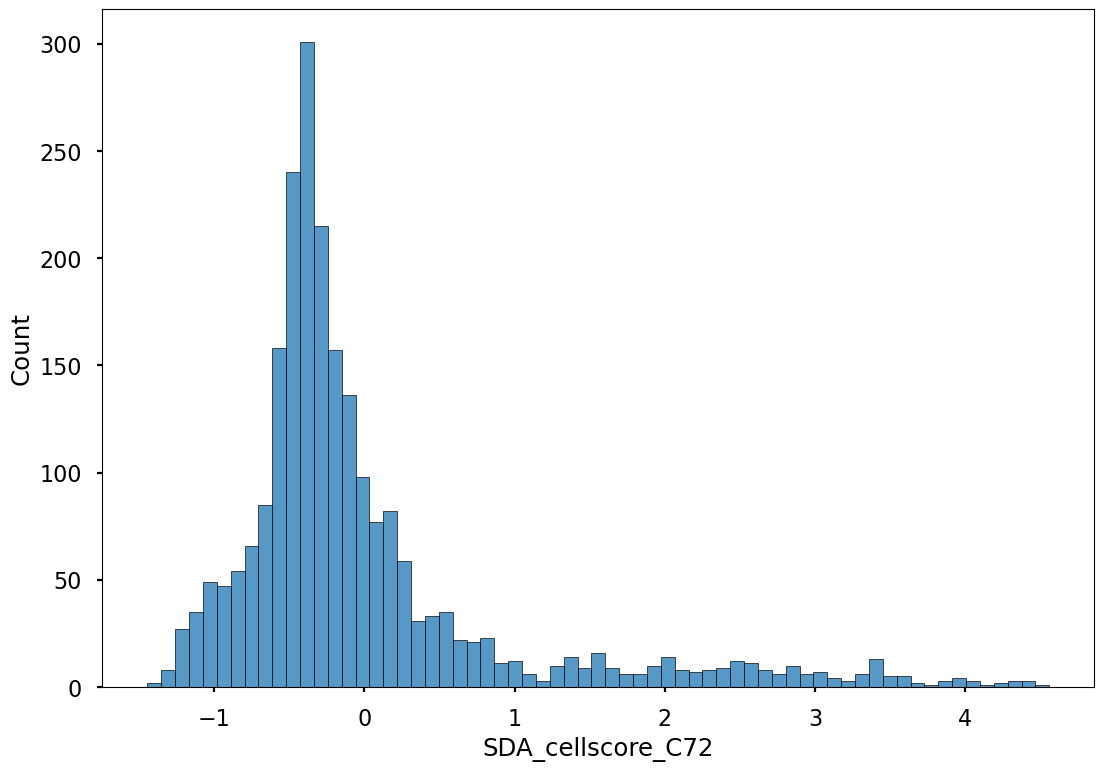

In [29]:
sns.histplot(adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'])

Genes significant for components (whole list printed to easy copy-pase for onlyne databases):

In [30]:
print(f'Genes significant for positive C{comp}:', adata[:,adata.var[f'sda_pos_C{comp}']].shape[1])

Genes significant for positive C72: 1993


In [31]:
for i in adata[:,adata.var[f'sda_pos_C{comp}']].var_names:
    print(i)

LOC469457
SLC2A5
SLC25A33
CTNNBIP1
C1H1orf167
SDF4
C1H1orf159
PRDM2
PLEKHM2
UBR4
MRTO4
HP1BP3
EIF4G3
SRSF10
WASF2
RPA2
DNAJC8
PHACTR4
SRSF4
PTP4A2
KHDRBS1
ZBTB8OS
RBBP4
ZMYM6
ZMYM1
ZMYM4
CLSPN
AGO4
AGO3
TRAPPC3
THRAP3
CDCA8
PABPC4
FOXJ3
CFAP57
ST3GAL3
ERI3
RNF220
ARMH1
KIF2C
ZSWIM5
TESK2
IPP
MAST2
PIK3R3
FAAH
EFCAB14
STIL
ZCCHC11
ECHDC2
DMRTB1
GLIS1
SSBP3
PLPP3
LOC742772
NFIA
ATG4C
ITGB3BP
WDR78
MIER1
DEPDC1
SRSF11
LRRIQ3
MSH4
PIGK
ZZZ3
USP33
NEXN
SPATA1
WDR63
SH3GLB1
LOC100615600
ZNF644
BRDT
BTBD8
EVI5
MTF2
ABCD3
PTBP2
DPYD
SASS6
LOC104001730
NTNG1
PRPF38B
GPSM2
KIAA1324
SORT1
GSTM4
LRIF1
TMIGD3
RAP1A
ST7L
CAPZA1
SLC16A1
RSBN1
TRIM33
MAN1A2
SPAG17
PHGDH
NOTCH2
LOC112208396
LOC112208384
MCL1
PIP5K1A
POGZ
NUP210L
TDRD10
ASH1L
GON4L
TSACC
PFDN2
UAP1
NUF2
TMCO1
ILDR2
ADCY10
DCAF6
TIPRL
BLZF1
DNM3
SUCO
TNFSF4
SLC9C2
ANKRD45
KLHL20
RC3H1
CACYBP
RASAL2
RALGPS2
AXDND1
TDRD5
ACBD6
SHCBP1L
RGL1
EDEM3
TRMT1L
SWT1
ODR4
LOC112206075
ASPM
CRB1
NEK7
ATP2B4
ZC3H11A
RCOR3
SLC30A1
LPGAT1
INTS7
CENPF
US

In [32]:
print(f'Genes significant for negative C{comp}:', adata[:,adata.var[f'sda_neg_C{comp}']].shape[1])

Genes significant for negative C72: 1036


In [33]:
for i in adata[:,adata.var[f'sda_neg_C{comp}']].var_names:
    print(i)

AURKAIP1
CEP104
RERE
UBE4B
MTOR
FHAD1
DDOST
LUZP1
ARID1A
FAM76A
EYA3
ATP5IF1
EPB41
ZCCHC17
PHC2
HMGB4
SCMH1
CCDC30
YBX1
RPS8
ATPAF1
AGBL4
ELAVL4
FAF1
NRDC
ZFYVE9
SCP2
TMEM59
TCEANC2
MROH7
LEXM
LOC107966822
JUN
DOCK7
JAK1
LOC100611288
LOC107966995
LOC107967064
ZRANB2
FUBP1
TTLL7
PKN2
HFM1
GLMN
BCAR3
ARHGAP29
RNPC3
VAV3
C1H1orf194
GSTM3
PIFO
SYCP1
HORMAD1
TCHH
RPS27
UBAP2L
PBXIP1
LOC107968845
CFAP45
LOC469572
LOC112204100
RABGAP1L
COP1
TEX35
RGSL1
LOC107969611
TROVE2
KCNT2
DENND1B
PPP1R12B
ETNK2
NUCKS1
SRGAP2
KCNH1
DISP1
SUSD4
ACBD3
PCNX2
LOC104004798
AKT3
MYT1L
NBAS
RAD51AP2
VSNL1
LDAH
UBXN2A
SRBD1
PRKCE
TMEM247
TTC7A
RPS27A
USP34
EHBP1
RAB1A
LOC100612620
APLF
PAIP2B
EXOC6B
C2AH2orf81
WDR54
TEKT4
BCL2L11
LOC749343
VWA3B
EIF5B
LOC112208197
MAP4K4
NPAS2
RANBP2
CCDC93
LOC107973756
GTDC1
RIF1
ITGB6
DHRS9
HAT1
PDK1
CHN1
PLEKHA3
TTN
CCDC141
ZNF804A
ZC3H15
ZSWIM2
LOC104005295
ANKAR
NABP1
ALS2CR12
SUMO1
BMPR2
CYP20A1
KLF7
RPL37A
TNP1
LOC101058385
SPATA3
PSMD1
GIGYF2
IQCA1
UBE2F
SCLY
LOC10797053

#### Cells scores by cluster

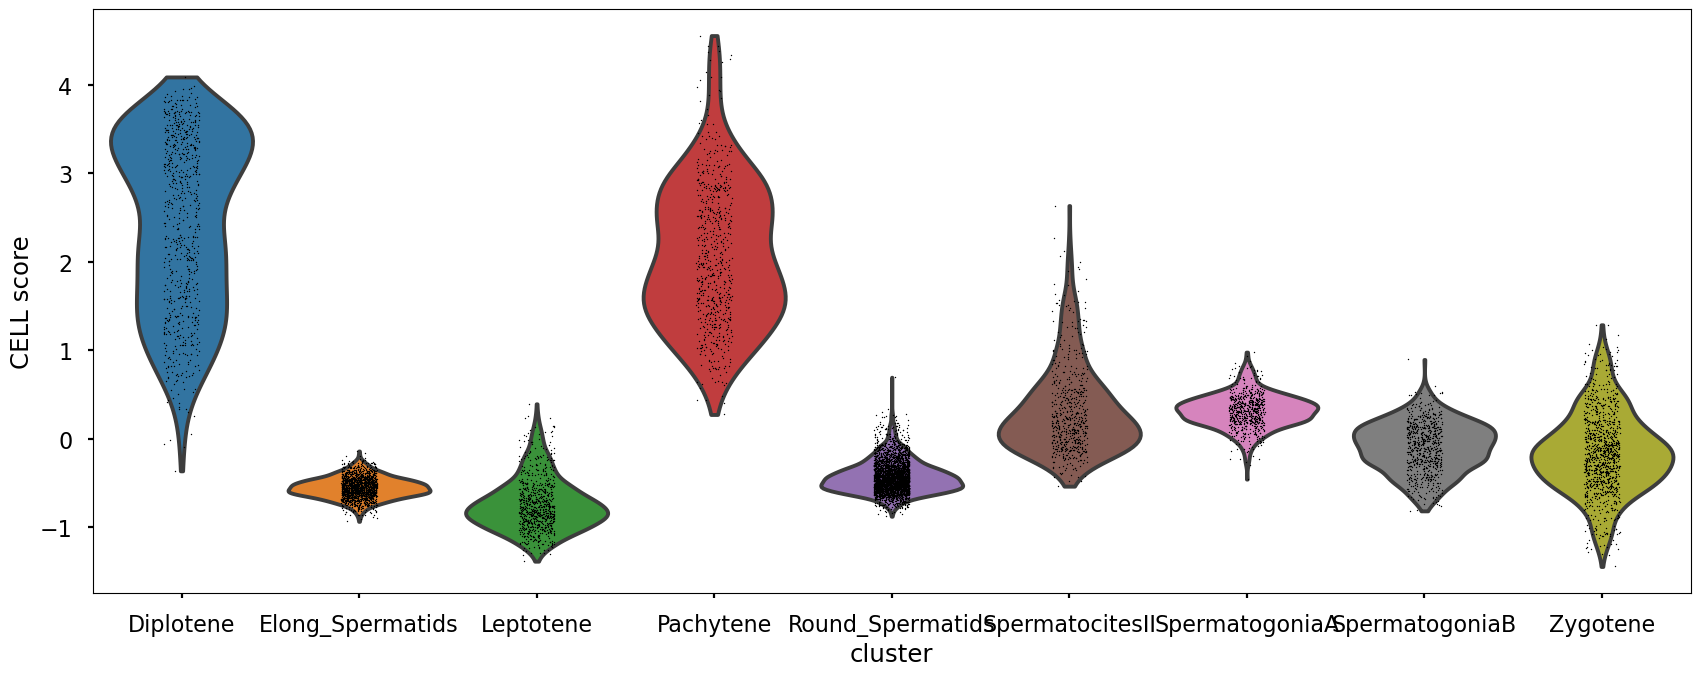

In [34]:
plt.rcParams['figure.figsize']=(16,8)
sc.pl.violin(adata, 
             groupby='spermatogenesis', keys=f'SDA_cellscore_C{comp}',
             title=f'CELLS score for SDA component C{comp}',
             xlabel='cluster', ylabel='CELL score')

(array([0, 1, 2, 3, 4, 5, 6, 7, 8]),
 [Text(0, 0, 'SpermatogoniaA'),
  Text(1, 0, 'SpermatogoniaB'),
  Text(2, 0, 'Leptotene'),
  Text(3, 0, 'Zygotene'),
  Text(4, 0, 'Pachytene'),
  Text(5, 0, 'Diplotene'),
  Text(6, 0, 'SpermatocitesII'),
  Text(7, 0, 'Round_Spermatids'),
  Text(8, 0, 'Elong_Spermatids')])

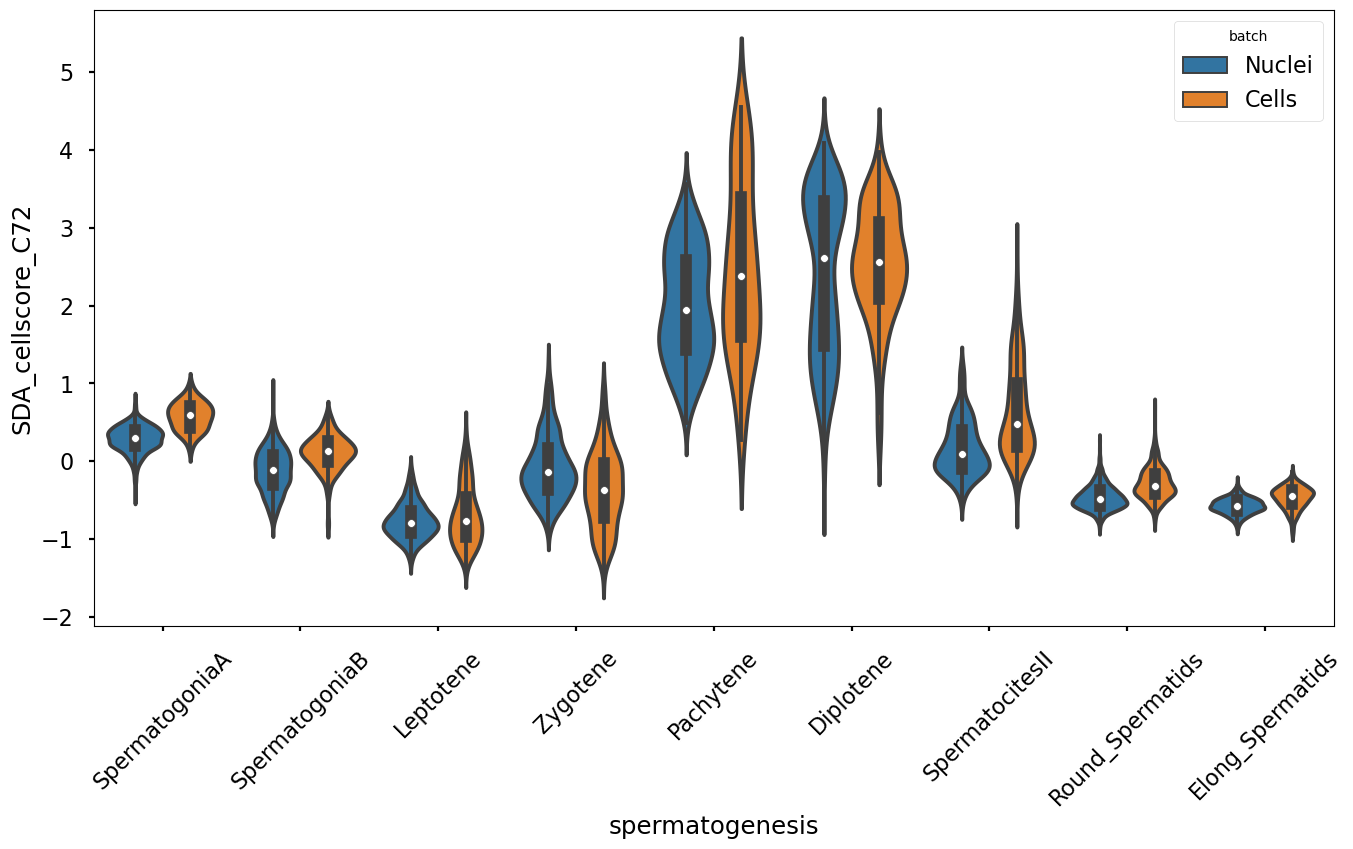

In [35]:
plt.rcParams['figure.figsize']=(16,8)
sns.violinplot(x='spermatogenesis', y=f'SDA_cellscore_C{comp}', hue='batch', data=adata.obs, 
               order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids'])
plt.xticks(rotation=45)

#### Cell scores by pseudotimes and relative threshold lines

In [36]:
score_neg = -2 #min( -2, np.quantile(A[int(comp)], .1) )
score_pos = 2 #max( +2, np.quantile(A[int(comp)], .9) )

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C72')

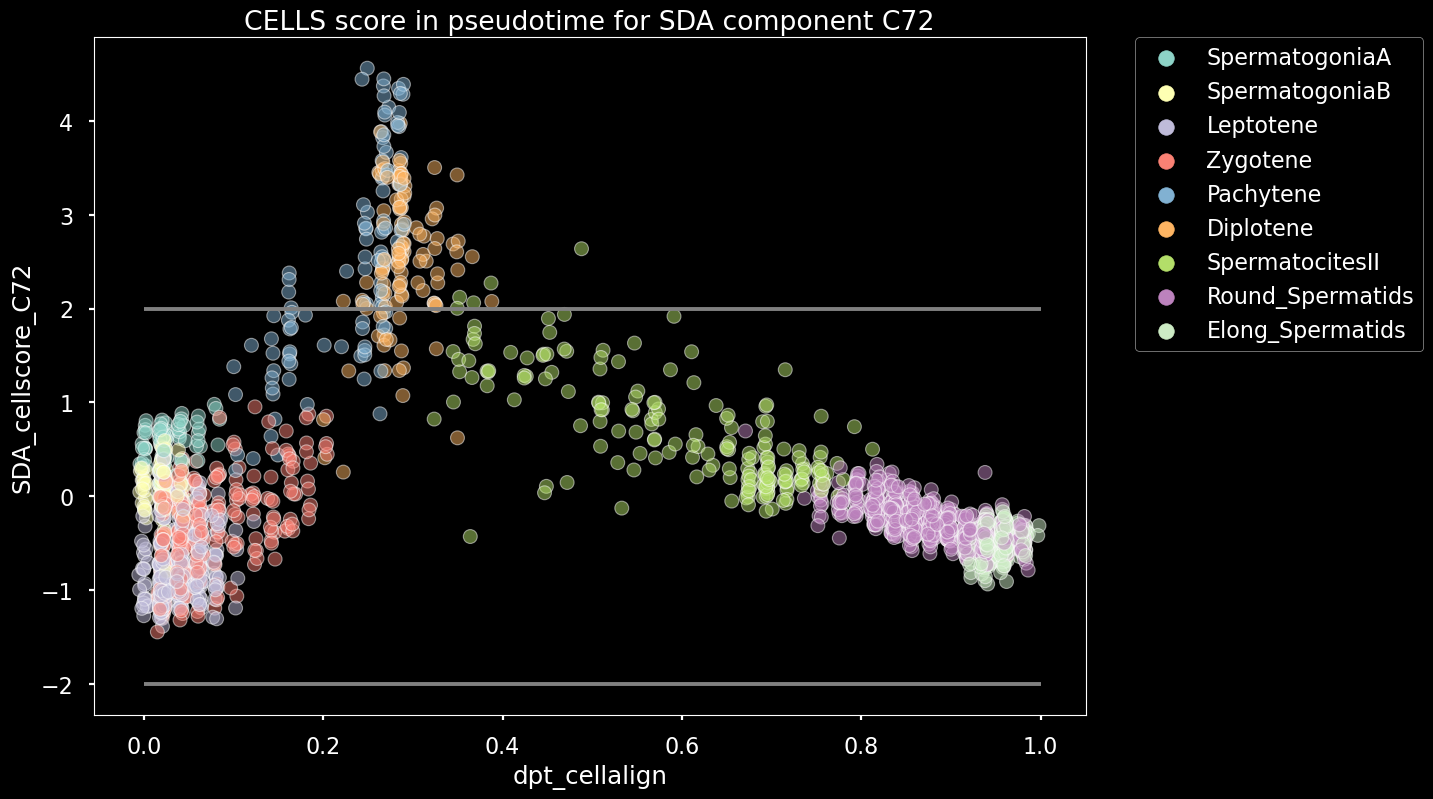

In [37]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'], 
           x=adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata[adata.obs['batch']=='Cells'].shape[0]),
           hue=adata[adata.obs['batch']=='Cells'].obs['spermatogenesis'],
           alpha=.5, ax=ax, s=100,
           hue_order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 
                      'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids']
           )
plt.hlines(score_neg, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C72')

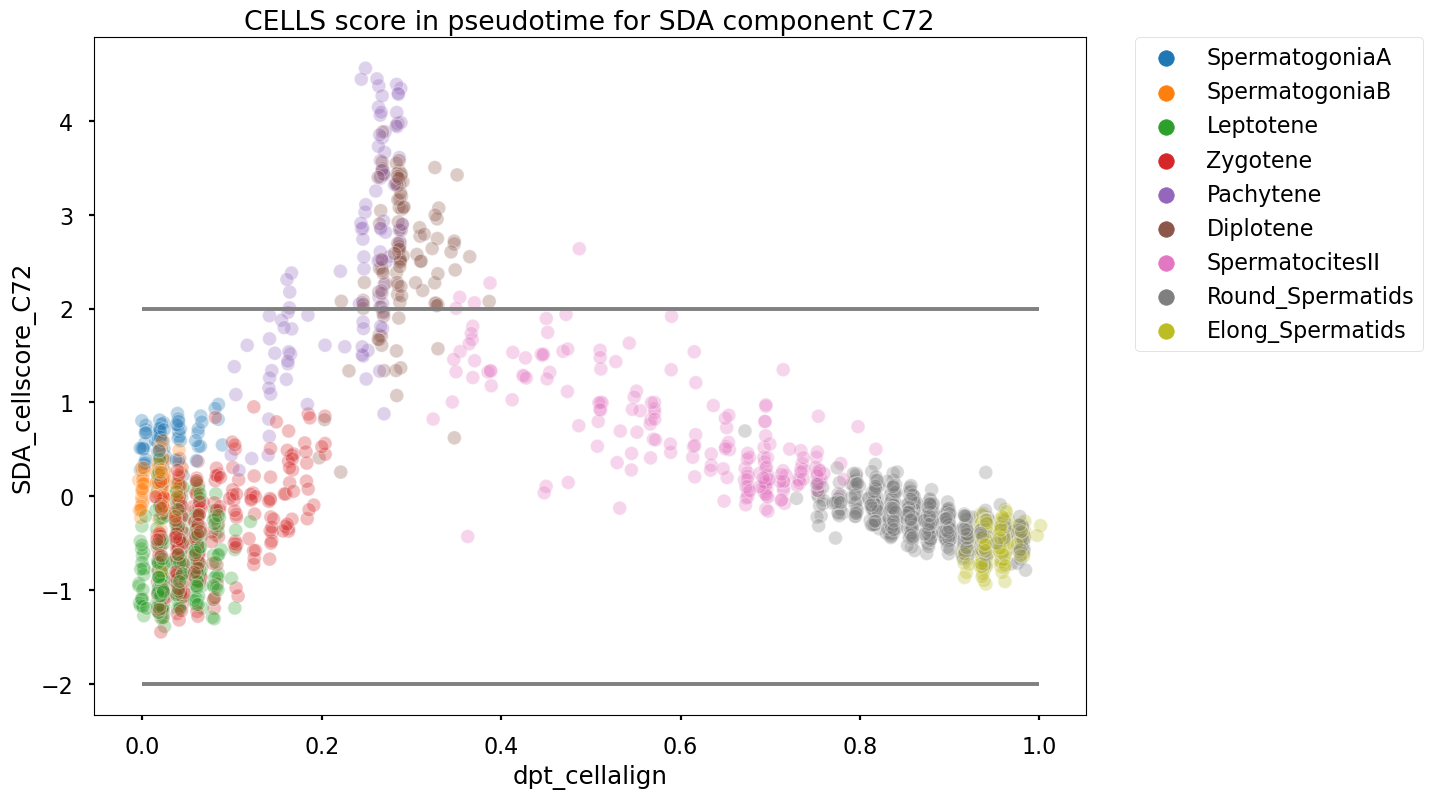

In [38]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'], 
           x=adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata[adata.obs['batch']=='Cells'].shape[0]),
           hue=adata[adata.obs['batch']=='Cells'].obs['spermatogenesis'],
           alpha=.3, ax=ax, s=100,
           hue_order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 
                      'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids']
           )
plt.hlines(score_neg, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C72')

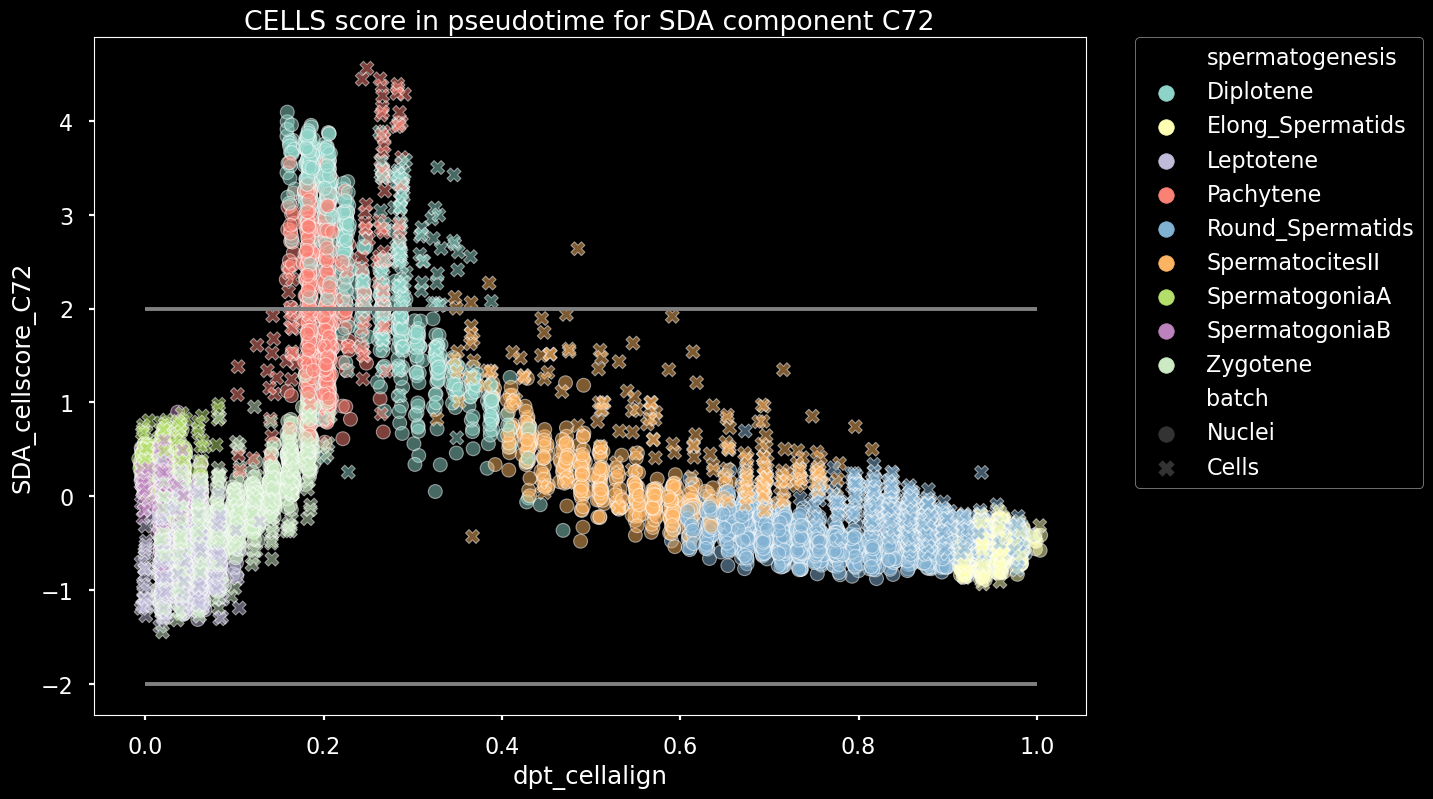

In [39]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata.obs[f'SDA_cellscore_C{comp}'],
           x=adata.obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata.shape[0]),
           hue=adata.obs['spermatogenesis'],
           style=adata.obs['batch'],
           alpha=.5, ax=ax, s=100)
plt.hlines(score_neg, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C72')

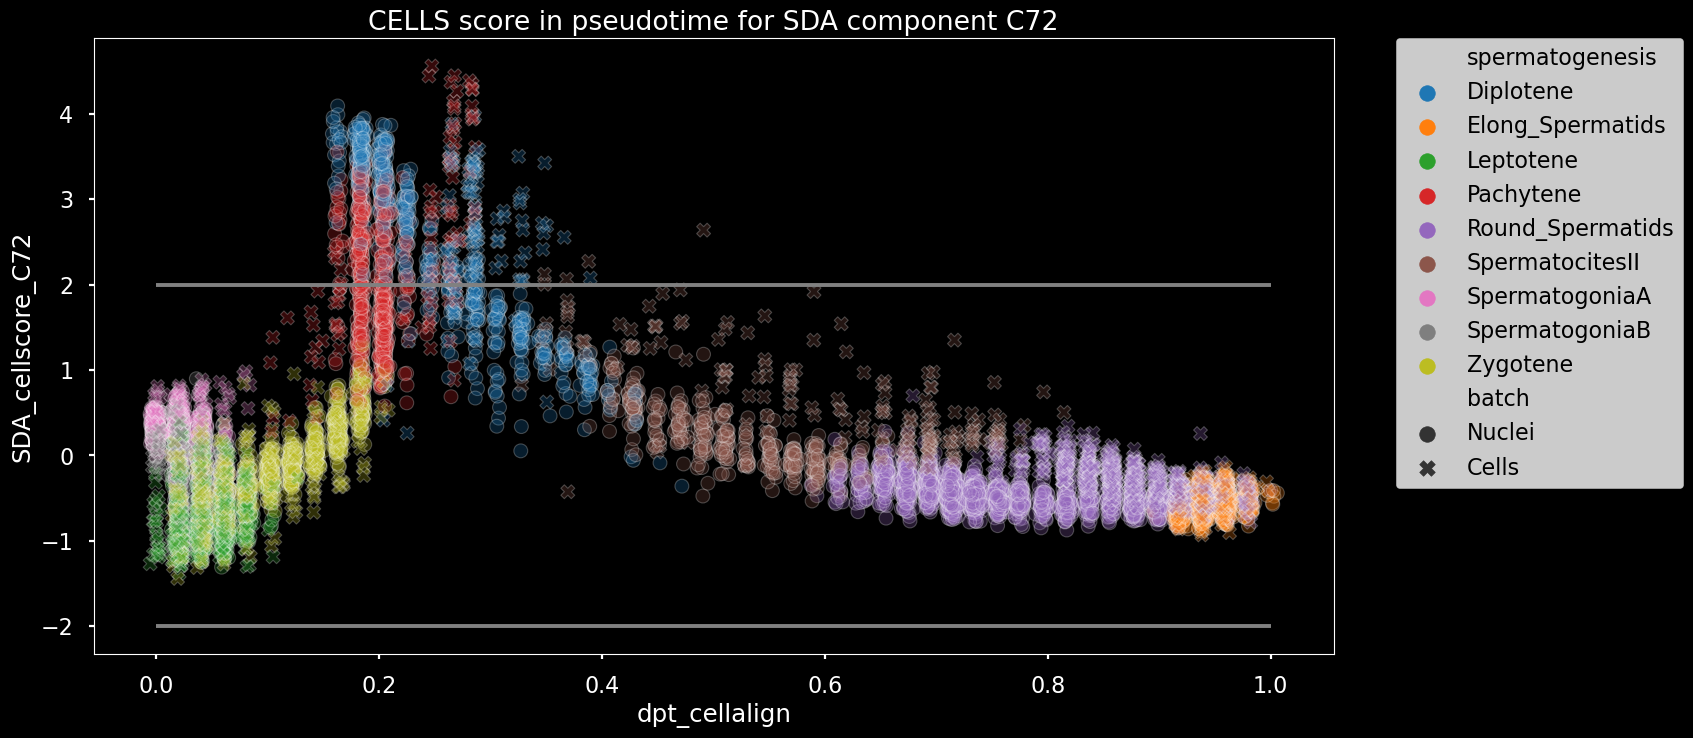

In [40]:
plt.rcParams['figure.figsize']=(16,8)
fig, ax = plt.subplots(1)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sns.scatterplot(y=adata.obs[f'SDA_cellscore_C{comp}'],
           x=adata.obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata.shape[0]),
           hue=adata.obs['spermatogenesis'],
           style=adata.obs['batch'],
           alpha=.25, ax=ax, s=100)
plt.hlines(score_neg, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

## Gene set enrichment analysis

In [41]:
import gseapy as gp

In [42]:
!mkdir -p ./enrichment

In [43]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [44]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )

In [45]:
enr.results[enr.results['Adjusted P-value']<.001]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
286,GO_Cellular_Component_2023,Nucleus (GO:0005634),549/4487,9.671988e-09,3.539948e-06,0,0,1.358291,25.065937,RB1;ATF2;TRRAP;GPATCH2;TESK2;SMC5;SMC6;RBPJ;SM...
287,GO_Cellular_Component_2023,Intracellular Membrane-Bounded Organelle (GO:0...,609/5175,4.171172e-07,7.633245e-05,0,0,1.295319,19.028111,RB1;ATF2;TRRAP;GPATCH2;TESK2;SMC5;SMC6;RBPJ;SM...
288,GO_Cellular_Component_2023,Cilium (GO:0005929),49/257,6.516889e-06,7.950604e-04,0,0,2.156910,25.755911,ROPN1B;FANK1;TRAF3IP1;CEP19;IFT52;IQUB;BBS9;TN...
652,Human_Gene_Atlas,TestisIntersitial,119/568,2.120932e-15,1.696746e-13,0,0,2.483168,83.898596,ROPN1B;ULK4;FBXO25;CASC1;CLGN;SPATA22;PPFIA1;Z...
653,Human_Gene_Atlas,TestisLeydigCell,29/107,3.913909e-07,1.565564e-05,0,0,3.394048,50.074288,SPAG17;PIWIL1;DDX25;NR2C2;CASC1;RNFT1;COIL;FBX...
654,Human_Gene_Atlas,TestisGermCell,55/314,2.426414e-05,6.470437e-04,0,0,1.944727,20.665659,PIWIL1;ULK4;CETN3;ATF7IP2;CEP164;DNHD1;LRRC6;S...


In [46]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [47]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None)

In [48]:
table_pos = enr.results[enr.results['Adjusted P-value']<.001][ ['Gene_set', 'Term', 'Overlap', 'Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes' ] ]

In [49]:
table_pos['Component'] = f'{comp}P'

In [50]:
table_pos['Batch diff'] = batch_effect_pos

In [51]:
table_pos['N cells'] = POSITIVE

In [52]:
table_pos

,Gene_set,Term,Overlap,Adjusted P-value,Odds Ratio,Combined Score,Genes,Component,Batch diff,N cells
286,GO_Cellular_Component_2023,Nucleus (GO:0005634),549/4487,3.539948e-06,1.358291,25.065937,RB1;ATF2;TRRAP;GPATCH2;TESK2;SMC5;SMC6;RBPJ;SM...,72P,No,987
287,GO_Cellular_Component_2023,Intracellular Membrane-Bounded Organelle (GO:0...,609/5175,7.633245e-05,1.295319,19.028111,RB1;ATF2;TRRAP;GPATCH2;TESK2;SMC5;SMC6;RBPJ;SM...,72P,No,987
288,GO_Cellular_Component_2023,Cilium (GO:0005929),49/257,7.950604e-04,2.156910,25.755911,ROPN1B;FANK1;TRAF3IP1;CEP19;IFT52;IQUB;BBS9;TN...,72P,No,987
652,Human_Gene_Atlas,TestisIntersitial,119/568,1.696746e-13,2.483168,83.898596,ROPN1B;ULK4;FBXO25;CASC1;CLGN;SPATA22;PPFIA1;Z...,72P,No,987
653,Human_Gene_Atlas,TestisLeydigCell,29/107,1.565564e-05,3.394048,50.074288,SPAG17;PIWIL1;DDX25;NR2C2;CASC1;RNFT1;COIL;FBX...,72P,No,987
654,Human_Gene_Atlas,TestisGermCell,55/314,6.470437e-04,1.944727,20.665659,PIWIL1;ULK4;CETN3;ATF7IP2;CEP164;DNHD1;LRRC6;S...,72P,No,987


In [53]:
table_pos.to_csv(f'enrichment/enrichr_C{comp}P.csv', header=False, index_label=False, index=None, sep='\t')

In [54]:
genes = list( adata[:,adata.var[f'sda_neg_C{comp}']].var_names )

In [55]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )

In [56]:
enr.results[enr.results['Adjusted P-value']<.001]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Ribosome,25/158,5.880019e-07,0.000151,0,0,3.501149,50.229359,RPL4;RPL3;RPS27L;RPL8;RPL9;RPS14;RPS15A;RPS19;...
1,KEGG_2021_Human,Coronavirus disease,30/232,3.709322e-06,0.000477,0,0,2.769817,34.635621,RPL4;RPL3;RPS27L;RPL8;RPL9;RPS14;C5;RPS15A;RPS...
257,GO_Cellular_Component_2023,Cytosolic Large Ribosomal Subunit (GO:0022625),15/52,3.451968e-08,0.000005,0,0,7.515287,129.125681,RPL4;RPL41;RPL3;RPL13A;RPL8;RPL9;RPL37A;RPL35;...
258,GO_Cellular_Component_2023,Large Ribosomal Subunit (GO:0015934),15/52,3.451968e-08,0.000005,0,0,7.515287,129.125681,RPL4;RPL41;RPL3;RPL13A;RPL8;RPL9;RPL37A;RPL35;...
259,GO_Cellular_Component_2023,Intracellular Non-Membrane-Bounded Organelle (...,104/1195,1.118831e-07,0.000011,0,0,1.828059,29.259562,RPL4;RIPOR2;NARF;RPL3;HSF2BP;NUCKS1;DEUP1;SMC3...
260,GO_Cellular_Component_2023,Chromosome (GO:0005694),26/164,3.382652e-07,0.000025,0,0,3.511809,52.323979,TOP2A;SYCP1;DDX21;NOL8;HSF2BP;BRCA1;SMC3;SMC2;...
261,GO_Cellular_Component_2023,Focal Adhesion (GO:0005925),41/387,1.166365e-05,0.000681,0,0,2.217266,25.185993,RPL4;BCAR3;FOCAD;RPL3;CD81;DOCK7;RPL8;RPL9;LPP...
262,GO_Cellular_Component_2023,Cell-Substrate Junction (GO:0030055),41/395,1.896194e-05,0.000796,0,0,2.166227,23.553549,RPL4;BCAR3;FOCAD;RPL3;CD81;DOCK7;RPL8;RPL9;LPP...
263,GO_Cellular_Component_2023,Nucleus (GO:0005634),288/4487,1.908822e-05,0.000796,0,0,1.353875,14.711797,RPL4;EIF4A1;TCERG1;RPL3;MYT1L;NEXMIF;MSANTD4;G...
549,Human_Gene_Atlas,TestisIntersitial,55/568,6.220246e-06,0.000479,0,0,2.016491,24.173088,TSKS;CALR3;CRISP2;CLPB;SYCP1;ICA1;AQP5;ALKBH7;...


In [57]:
table_neg = enr.results[enr.results['Adjusted P-value']<.001][ ['Gene_set', 'Term', 'Overlap', 'Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes' ] ]

In [58]:
table_neg['Component'] = f'{comp}N'

In [59]:
table_neg['Batch diff'] = batch_effect_neg

In [60]:
table_neg['N cells'] = NEGATIVE

In [61]:
table_neg

,Gene_set,Term,Overlap,Adjusted P-value,Odds Ratio,Combined Score,Genes,Component,Batch diff,N cells
0,KEGG_2021_Human,Ribosome,25/158,0.000151,3.501149,50.229359,RPL4;RPL3;RPS27L;RPL8;RPL9;RPS14;RPS15A;RPS19;...,72N,No,0
1,KEGG_2021_Human,Coronavirus disease,30/232,0.000477,2.769817,34.635621,RPL4;RPL3;RPS27L;RPL8;RPL9;RPS14;C5;RPS15A;RPS...,72N,No,0
257,GO_Cellular_Component_2023,Cytosolic Large Ribosomal Subunit (GO:0022625),15/52,0.000005,7.515287,129.125681,RPL4;RPL41;RPL3;RPL13A;RPL8;RPL9;RPL37A;RPL35;...,72N,No,0
258,GO_Cellular_Component_2023,Large Ribosomal Subunit (GO:0015934),15/52,0.000005,7.515287,129.125681,RPL4;RPL41;RPL3;RPL13A;RPL8;RPL9;RPL37A;RPL35;...,72N,No,0
259,GO_Cellular_Component_2023,Intracellular Non-Membrane-Bounded Organelle (...,104/1195,0.000011,1.828059,29.259562,RPL4;RIPOR2;NARF;RPL3;HSF2BP;NUCKS1;DEUP1;SMC3...,72N,No,0
260,GO_Cellular_Component_2023,Chromosome (GO:0005694),26/164,0.000025,3.511809,52.323979,TOP2A;SYCP1;DDX21;NOL8;HSF2BP;BRCA1;SMC3;SMC2;...,72N,No,0
261,GO_Cellular_Component_2023,Focal Adhesion (GO:0005925),41/387,0.000681,2.217266,25.185993,RPL4;BCAR3;FOCAD;RPL3;CD81;DOCK7;RPL8;RPL9;LPP...,72N,No,0
262,GO_Cellular_Component_2023,Cell-Substrate Junction (GO:0030055),41/395,0.000796,2.166227,23.553549,RPL4;BCAR3;FOCAD;RPL3;CD81;DOCK7;RPL8;RPL9;LPP...,72N,No,0
263,GO_Cellular_Component_2023,Nucleus (GO:0005634),288/4487,0.000796,1.353875,14.711797,RPL4;EIF4A1;TCERG1;RPL3;MYT1L;NEXMIF;MSANTD4;G...,72N,No,0
549,Human_Gene_Atlas,TestisIntersitial,55/568,0.000479,2.016491,24.173088,TSKS;CALR3;CRISP2;CLPB;SYCP1;ICA1;AQP5;ALKBH7;...,72N,No,0


In [62]:
table_neg.to_csv(f'enrichment/enrichr_C{comp}N.csv', header=False, index_label=False, index=None, sep='\t')

## Plot genes average expression for positive and negative module

In [63]:
!mkdir -p ./plots

In [64]:
adata.layers

Layers with keys: SCT_counts, correct_counts, raw_counts, scaled_counts, spliced, unspliced

In [65]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [66]:
adata.obs[f'module_pos_C{comp}'] = np.array( np.mean(adata[:,genes].layers['scaled_counts'], 1) )

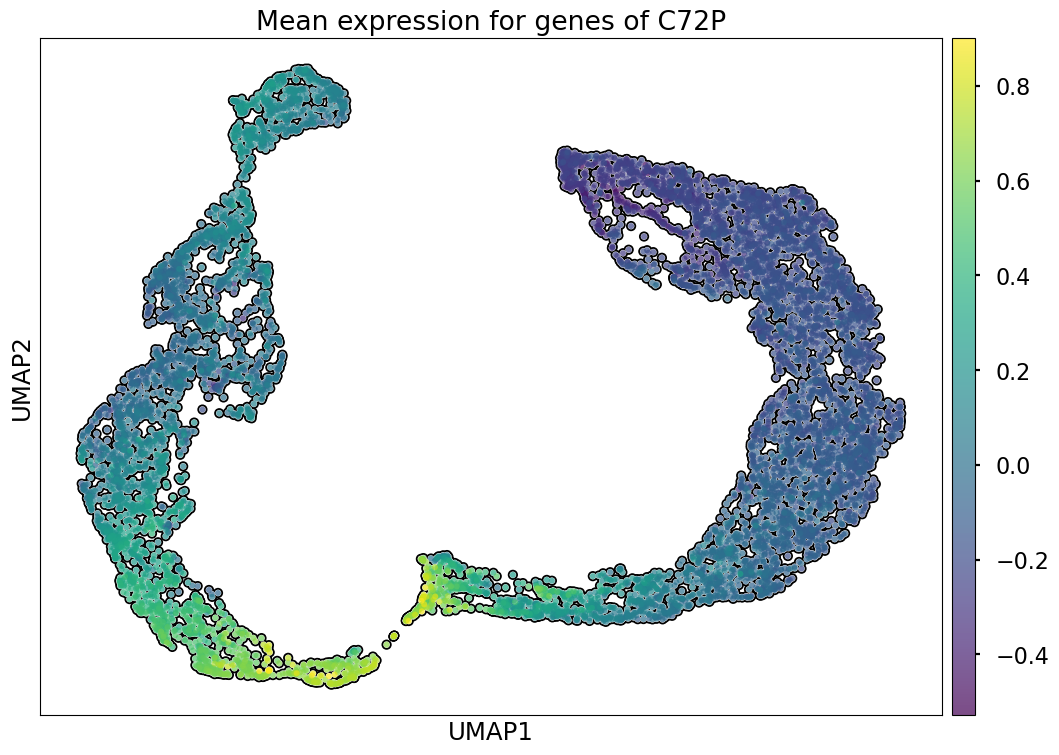

In [67]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_pos_C{comp}'], 
           add_outline=True, 
           save=f'genes_C{comp}P_white.png',
           title=f'Mean expression for genes of C{comp}P', size=75)

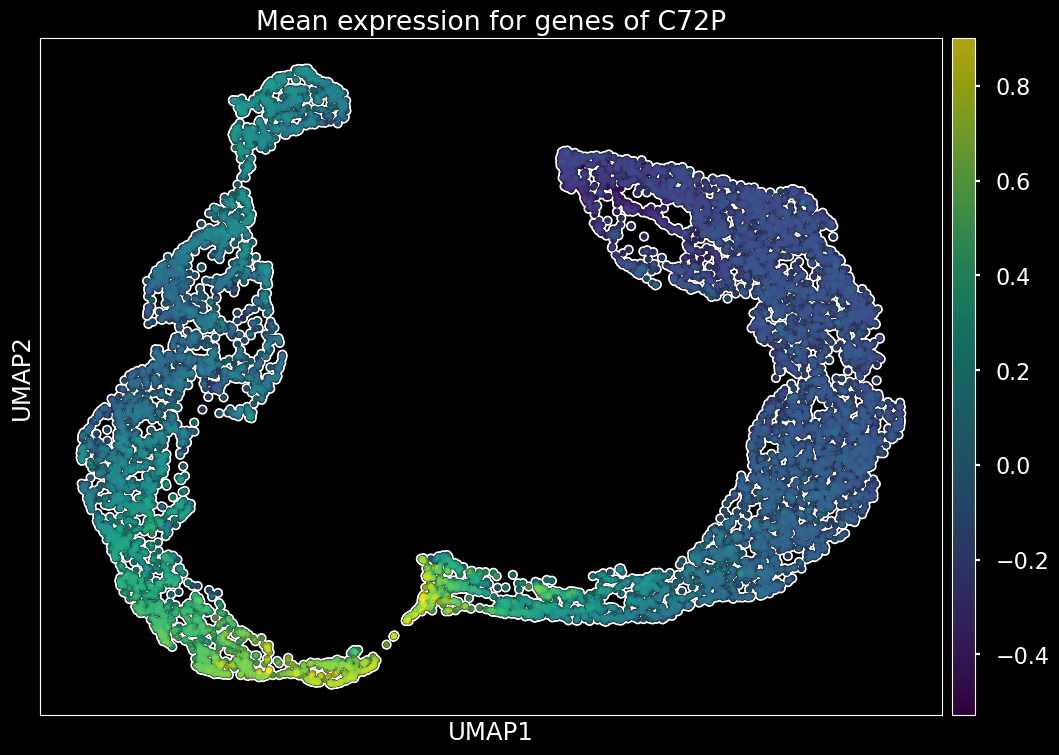

In [68]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_pos_C{comp}'], 
           add_outline=True, outline_color=['white','black'],
           save=f'genes_C{comp}P_dark.png',
           title=f'Mean expression for genes of C{comp}P', size=75)

In [69]:
genes = list( adata[:,adata.var[f'sda_neg_C{comp}']].var_names )

In [70]:
adata.obs[f'module_neg_C{comp}'] = np.array( np.mean(adata[:,genes].layers['SCT_counts'], 1) )

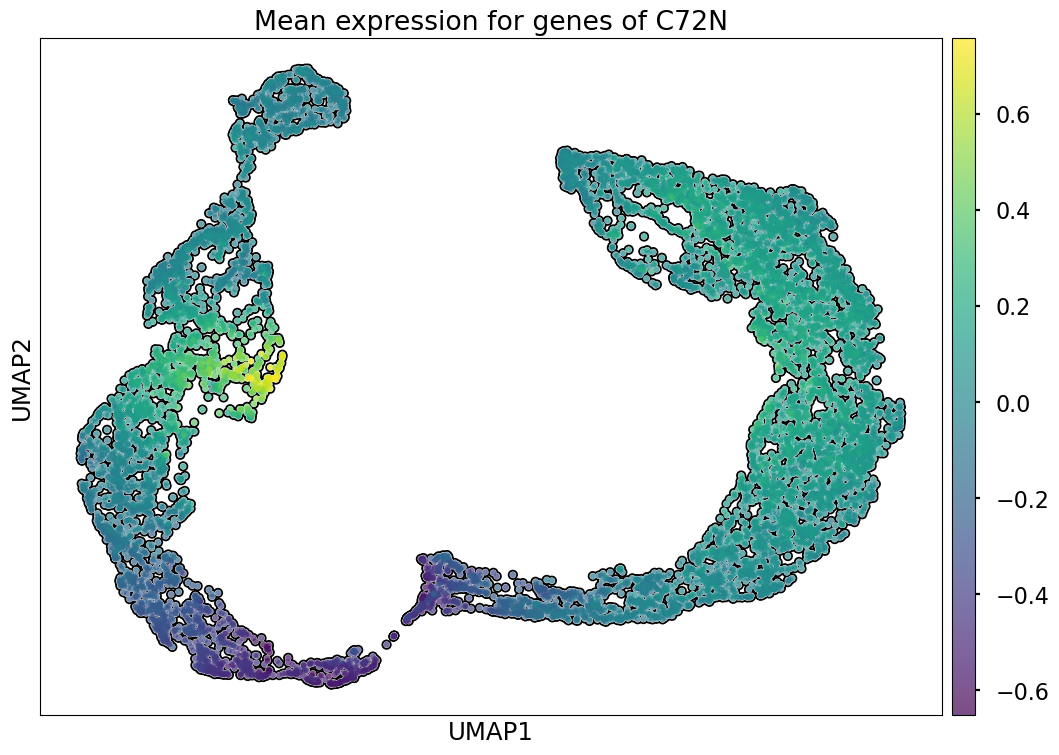

In [71]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_neg_C{comp}'], 
           add_outline=True, 
           save=f'genes_C{comp}N_white.png',
           title=f'Mean expression for genes of C{comp}N', size=75)

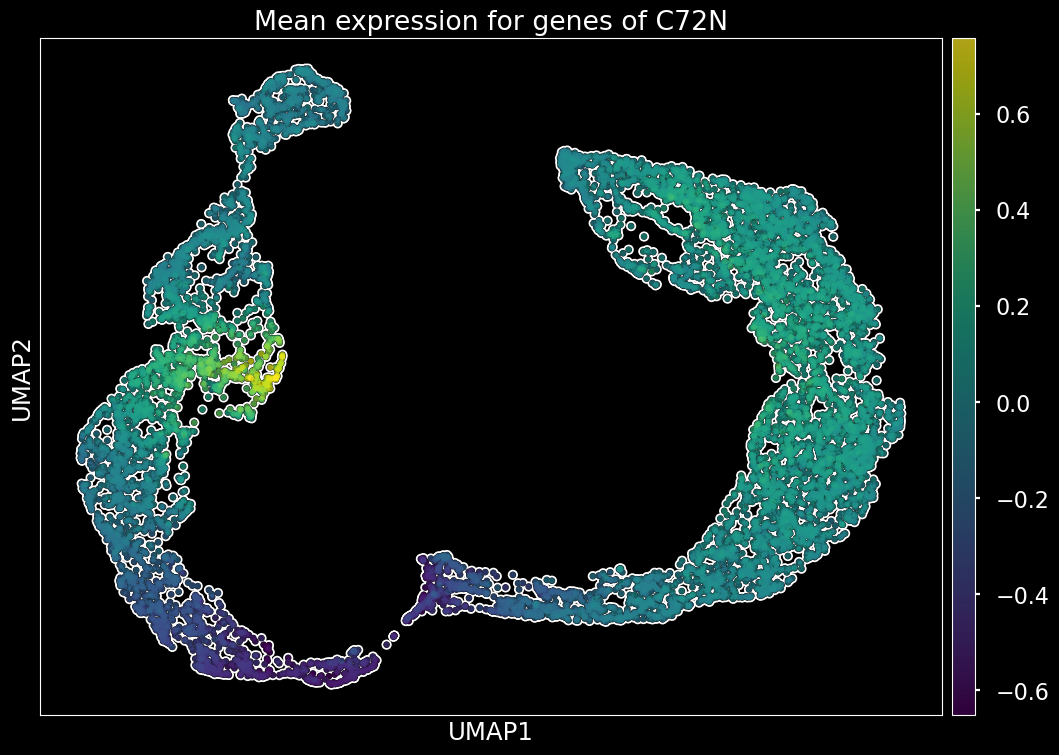

In [72]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_neg_C{comp}'], 
           add_outline=True, outline_color=['white','black'],
           save=f'genes_C{comp}N_dark.png',
           title=f'Mean expression for genes of C{comp}N', size=75)